In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')
df.shape

(3554, 18)

In [4]:
df.head(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7586.0,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
1,flat,smart world gems,sector 89,0.95,8597.0,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0
2,flat,breez global hill view,sohna road,0.32,5470.0,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0
4,flat,suncity avenue,sector 102,0.48,9023.0,2.0,2.0,1,5.0,Relatively New,581.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0


In [5]:
train_df = df.drop(columns=['society','price_per_sqft']);

In [6]:
train_df.head(5)

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 36,0.82,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
1,flat,sector 89,0.95,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0
2,flat,sohna road,0.32,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
3,flat,sector 92,1.60,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0
4,flat,sector 102,0.48,2.0,2.0,1,5.0,Relatively New,581.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0


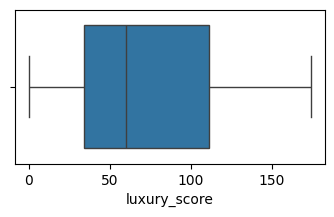

In [7]:
plt.figure(figsize=(4, 2))
sns.boxplot(x=df['luxury_score'])
plt.show()

In [8]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None

In [9]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

<Axes: xlabel='floorNum'>

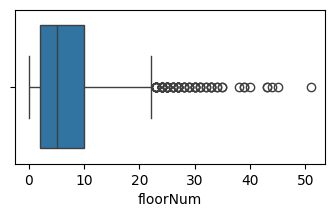

In [10]:
plt.figure(figsize = (4,2))
sns.boxplot(x = df['floorNum'])

In [11]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None 

In [12]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [13]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [14]:

train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 36,0.82,3.0,2.0,2,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,Low,Low Floor
1,flat,sector 89,0.95,2.0,2.0,2,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,Low,Mid Floor
2,flat,sohna road,0.32,2.0,2.0,1,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,Low,High Floor
3,flat,sector 92,1.60,3.0,4.0,3+,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,High,Mid Floor
4,flat,sector 102,0.48,2.0,2.0,1,Relatively New,581.0,0.0,0.0,1.0,0.0,0.0,0.0,High,Mid Floor


In [15]:
from sklearn.preprocessing import OrdinalEncoder

data_label_encoded = train_df.copy()
categorical_cols = train_df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 10', 'sector 102', 'sector 103', 'sector 104',
       'sector 105', 'sector 106', 'sector 107', 'sector 108',
       'sector 109', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 30', 'sector 31', 'sector 33',
       'sector 36', 'sector 37', 'sector 37d', 'sector 38', 'sector 39',
       'sector 4', 'sector 40', 'sector 41', 'sector 43', 'sector 45',
       'sector 46', 'sector 47', 'sector 48', 'sector 49', 'sector 5',
       'sector 50', 'sector 51', 'sector 52', 'sector 53', 'sector 54',
       'sector 55', 'sector 56', 'sector 57', 'sector 58', 'sector 59',
       'sector 6', 'sector 60', 'sector 61', 'sector 62', 

<Axes: >

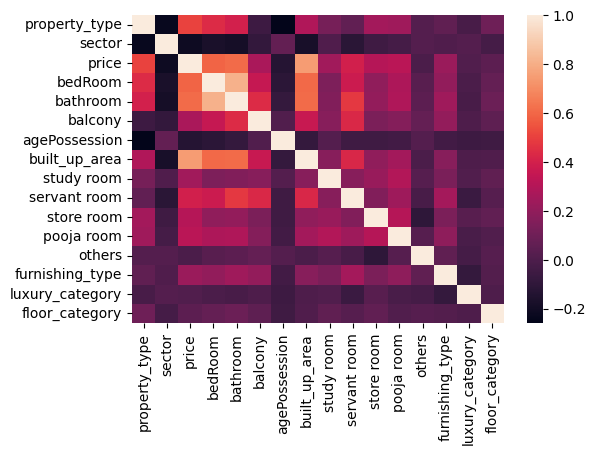

In [16]:
plt.figure(figsize = (6,4))
sns.heatmap(data_label_encoded.corr())

In [17]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.212084
1,price,1.000000
2,bedRoom,0.591289
3,bathroom,0.609777
4,balcony,0.269637
5,agePossession,-0.134171
6,built_up_area,0.748595
7,study room,0.242955
8,servant room,0.391930
9,store room,0.305677


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.650478
1,sector,0.102518
0,property_type,0.100240
3,bathroom,0.026779
2,bedRoom,0.023272
8,servant room,0.019427
5,agePossession,0.014505
4,balcony,0.012660
12,furnishing_type,0.010261
7,study room,0.008513


In [19]:
from sklearn.ensemble import GradientBoostingRegressor

gb_label = GradientBoostingRegressor()
gb_label.fit(X_label , y_label)

fi_df3 = pd.DataFrame({
    'feature' : X_label.columns,
    'gb_importance' : gb_label.feature_importances_
}).sort_values(by = 'gb_importance' , ascending = False)
fi_df3

,feature,gb_importance
6,built_up_area,0.678625
1,sector,0.105728
0,property_type,0.097008
3,bathroom,0.037272
2,bedRoom,0.036481
8,servant room,0.021734
9,store room,0.009731
5,agePossession,0.004389
7,study room,0.003808
12,furnishing_type,0.002459


In [20]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)
fi_df4

,feature,permutation_importance
6,built_up_area,7.363922e-01
0,property_type,1.990823e-01
1,sector,1.795679e-01
8,servant room,2.022338e-02
3,bathroom,1.896754e-02
2,bedRoom,1.867454e-02
5,agePossession,5.881541e-03
4,balcony,1.406922e-03
14,floor_category,1.060408e-03
13,luxury_category,8.142124e-04


In [24]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler();
X_scaled = scaler.fit_transform(X_label);

lasso = Lasso(alpha = 0.01 , random_state = 42);
lasso.fit(X_scaled , y_label);

fi_df5 = pd.DataFrame({
    'feature' : X_label.columns,
    'lasso_coef' : lasso.coef_
}).sort_values(by = 'lasso_coef' , ascending = False);
fi_df5

,feature,lasso_coef
6,built_up_area,1.510193
0,property_type,0.713738
3,bathroom,0.275067
9,store room,0.199656
7,study room,0.171844
12,furnishing_type,0.164079
8,servant room,0.160633
10,pooja room,0.073821
13,luxury_category,0.055286
2,bedRoom,0.014162


In [25]:
from sklearn.feature_selection import RFE
estimator = RandomForestRegressor()

selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

selected_features = X_label.columns[selector_label.support_]
selected_coefficients = selector_label.estimator_.feature_importances_

fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
6,built_up_area,0.643295
1,sector,0.108256
0,property_type,0.104373
2,bedRoom,0.024589
3,bathroom,0.023908
8,servant room,0.020938
5,agePossession,0.014756
4,balcony,0.012432
12,furnishing_type,0.009512
9,store room,0.008684


In [32]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import shap

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

ModuleNotFoundError: No module named 'shap'

In [34]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

NameError: name 'shap_values' is not defined

In [35]:
from sklearn.model_selection import cross_val_score
rf = RandomForestRegressor(n_estimators=100, random_state=42)
scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [36]:
scores.mean()

np.float64(0.8197904364181128)

In [37]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [38]:
scores.mean()

np.float64(0.818580052636696)

In [39]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [40]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)